In [1]:
import numpy as np
import pandas as pd
import sklearn.linear_model as sk_lm
import matplotlib.pyplot as plt
import sklearn.neighbors as skl_nb
import sklearn.preprocessing as skl_pre
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:

import helper
X, y = helper.load_data()   

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=helper.RANDOM_STATE, stratify=y
)

X_train = helper.pre_process_training_data(X_train_raw)
X_test = helper.pre_process_training_data(X_test_raw)



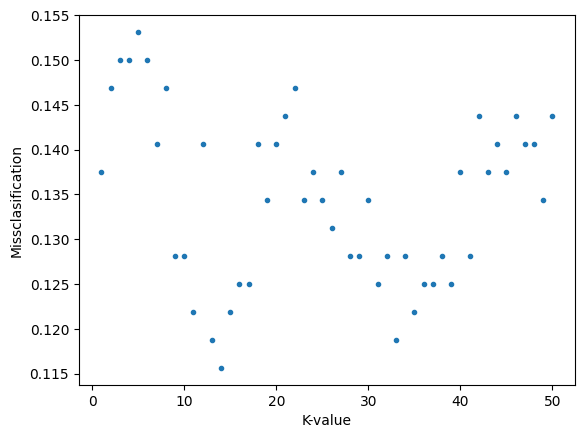

In [3]:

scaler = skl_pre.StandardScaler().fit(X_train)
model = skl_nb.KNeighborsClassifier(n_neighbors=11)
missclass = []
for k in range(1,51):

    model = skl_nb.KNeighborsClassifier(n_neighbors=k)

    model.fit(scaler.transform(X_train),y_train)

    prediction = model.predict(scaler.transform(X_test))
    missclass.append(np.mean(prediction != y_test))
K = np.linspace(1,50,50)
plt.ylabel('Missclasification')
plt.xlabel('K-value')
plt.plot(K,missclass,'.')

In [5]:

scaler = skl_pre.StandardScaler().fit(X_train)
model = skl_nb.KNeighborsClassifier(n_neighbors=11)
model.fit(scaler.transform(X_train),y_train)
prediction = model.predict(scaler.transform(X_test))
print("Accuracy:", accuracy_score(y_test, prediction))
print(classification_report(y_test, prediction))

Accuracy: 0.878125
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       262
           1       0.76      0.48      0.59        58

    accuracy                           0.88       320
   macro avg       0.83      0.72      0.76       320
weighted avg       0.87      0.88      0.87       320

